<a href="https://colab.research.google.com/github/beksultann-GQ/Bexs_work/blob/main/01_feature_importance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Зертханалық жұмыс 1: Модельдерді интерпретациялау — Feature Importance және Permutation Importance


Бұл зертханалық жұмыста сіз машиналық оқыту модельдерінің қалай шешім қабылдайтынын түсінуге арналған екі негізгі әдіспен танысасыз: модельдің ішіндегі белгілердің маңыздылығы (built-in feature importance) және пермутациялық маңыздылық (permutation importance). Жұмыс соңында сіз кез келген тұтастық түріндегі (tabular) деректер бойынша модельдің қандай белгілерге сүйенетінін бағалай алатын боласыз.

## Оқу мақсаттары

Осы зертханалық жұмысты орындау барысында студент төмендегі дағдыларды меңгеруі тиіс. Біріншіден, ағаш негізіндегі модельдердің (Random Forest, Gradient Boosting) ішкі feature_importances_ атрибутын дұрыс есептеп, интерпретациялау. Екіншіден, permutation_importance функциясын қолдана отырып, модельге тәуелсіз (model-agnostic) маңыздылықты өлшеу. Үшіншіден, екі әдісті салыстыру арқылы олардың артықшылықтары мен шектеулерін ажырата білу. Төртіншіден, нәтижелерді визуализациялау және академиялық тұрғыда сипаттау.

## Жұмыс құрылымы

1-бөлім. Ортаны дайындау және деректерді жүктеу.
2-бөлім. Модельді оқыту (Random Forest классификаторы).
3-бөлім. Модельдің кіріктірілген feature importance мәндері.
4-бөлім. Permutation importance есептеу.
5-бөлім. Екі әдісті салыстыру.
6-бөлім. Рефлексия және қорытынды сұрақтар.

## 1-бөлім. Ортаны дайындау

Алдымен қажетті кітапханаларды импорттаймыз. Егер орта бос болса, төмендегі pip-командасын іске қосыңыз. IBM Skills Network және Coursera лабораторияларында әдетте бұл кітапханалар алдын ала орнатылған болады.

In [ ]:
# Қажет болған жағдайда орнату
# !pip install scikit-learn pandas numpy matplotlib seaborn

In [2]:
# Негізгі кітапханаларды импорттау
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Модельдер мен көмекші функциялар
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, classification_report

# Кездейсоқтықты бекітеміз, нәтижелер қайталанатын болады
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Графиктердің жалпы стилі
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 2-бөлім. Деректерді жүктеу және дайындау

Бұл жұмыста біз классикалық Titanic деректер жинағын қолданамыз. Әр жолақ бір жолаушы туралы ақпаратты сипаттайды, ал мақсатты айнымалы survived (тірі қалды/қалмады) — бинарлы классификация есебі. OpenML арқылы деректерді тікелей жүктеп аламыз.

In [3]:
# Titanic деректер жинағын жүктеу
titanic = fetch_openml("titanic", version=1, as_frame=True)
df = titanic.frame.copy()

# Алғашқы бес жолды көру
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


### ### TODO ###

Төмендегі ұяшықта df деректерінің формасын (shape), баған атауларын және әр бағанның типін шығарыңыз. Бұл қадам барлық ML жұмысының бірінші міндетті кезеңі болып саналады.

In [5]:
### ### TODO ###
# 1. Деректердің өлшемін шығарыңыз
print(df.shape)

# 2. Баған атауларының тізімін алыңыз
print(df.columns.tolist())

# 3. Әр бағанның деректер типін көрсетіңіз
print(df.dtypes)

(1309, 14)
['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest']
pclass          int64
survived     category
name              str
sex          category
age           float64
sibsp           int64
parch           int64
ticket            str
fare          float64
cabin             str
embarked     category
boat              str
body          float64
home.dest         str
dtype: object


Әрі қарай модельге беруге ыңғайлы етіп деректерді тазалаймыз. Мұнда мақсатымыз — интерпретация әдістерін үйрену болғандықтан, feature engineering бөлігін қысқа ұстаймыз.

In [6]:
# Модельге қажет белгілерді ғана таңдаймыз
selected = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked", "survived"]
df = df[selected].copy()

# Бос мәндерді толтырамыз: сандық — медианамен, категориялық — модамен
df["age"] = df["age"].fillna(df["age"].median())
df["fare"] = df["fare"].fillna(df["fare"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

# Категориялық белгілерді сандық түрге ауыстырамыз (one-hot encoding)
df_encoded = pd.get_dummies(df, columns=["sex", "embarked"], drop_first=True)

# Мақсатты айнымалыны бөлеміз
y = df_encoded["survived"].astype(int)
X = df_encoded.drop(columns=["survived"])

X.head()

,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S
0,1,29.0000,0,0,211.3375,False,False,True
1,1,0.9167,1,2,151.5500,True,False,True
2,1,2.0000,1,2,151.5500,False,False,True
3,1,30.0000,1,2,151.5500,True,False,True
4,1,25.0000,1,2,151.5500,False,False,True


### ### TODO ###

Деректерді оқу және тест жиынтықтарына бөліңіз. Тест үлесі 25% болсын, стратификациялау мақсатты айнымалы бойынша жүргізілсін. random_state параметрі бұрын анықталған RANDOM_STATE мәнін пайдалансын.

In [8]:
### ### TODO ###
# Жиынтықты бөлу
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Оқу жиынтығы:", X_train.shape)
print("Тест жиынтығы:", X_test.shape)

Оқу жиынтығы: (1047, 8)
Тест жиынтығы: (262, 8)


## 3-бөлім. Random Forest моделін оқыту

Random Forest — интерпретация есептері үшін ыңғайлы модель, себебі оның ішінде әр белгінің үлесін бағалауға арналған feature_importances_ атрибуты бар. Модельді оқытып, тест жиынтығындағы дәлдігін бағалайық.

### ### TODO ###

Төмендегі кодта Random Forest классификаторының параметрлерін толықтырыңыз. Ағаштар саны 300, максималды тереңдігі 8, random_state бекітілген болсын.

In [9]:
## ### TODO ###
# Модельді инициализациялау
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

# Модельді оқыту
rf_model.fit(X_train, y_train)

# Тест жиынтығында болжам жасау
y_pred = rf_model.predict(X_test)

# Дәлдікті есептеу
acc = accuracy_score(y_test, y_pred)
print(f"Тест дәлдігі: {acc:.4f}")

Тест дәлдігі: 0.8626


In [10]:
# Модельдің толық есептемесін көреміз
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.94      0.89       162
           1       0.88      0.74      0.80       100

    accuracy                           0.86       262
   macro avg       0.87      0.84      0.85       262
weighted avg       0.86      0.86      0.86       262



## 4-бөлім. Кіріктірілген Feature Importance

Random Forest әр белгі бойынша бөлудің қаншалықты пайдалы болғанын Gini төмендеуі (mean decrease in impurity, MDI) арқылы бағалайды. Бұл шама feature_importances_ атрибутында сақталады және барлық мәндерінің қосындысы 1-ге тең.

In [11]:
# Кіріктірілген маңыздылықты DataFrame түрінде жинау
importances_builtin = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

importances_builtin

,feature,importance
5,sex_male,0.450675
4,fare,0.173015
0,pclass,0.129981
1,age,0.107754
2,sibsp,0.055946
3,parch,0.047071
7,embarked_S,0.027076
6,embarked_Q,0.008483


### ### TODO ###

Жоғарыдағы кестені горизонтальді бағаналы диаграмма (horizontal bar chart) арқылы визуализациялаңыз. X осіне — маңыздылық мәні, Y осіне — белгі атауы қойылсын. Ең маңызды белгі жоғарыда орналасуы керек.

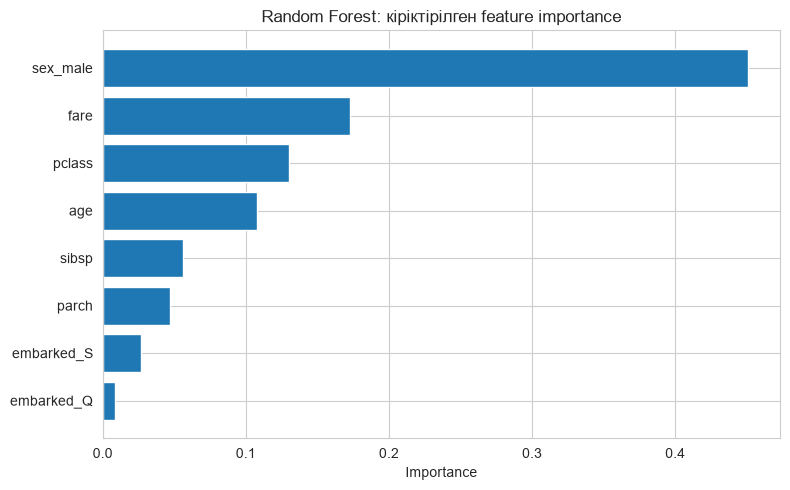

In [14]:
## ### TODO ###
plt.figure(figsize=(8, 5))
plt.barh(importances_builtin["feature"], importances_builtin["importance"])
plt.gca().invert_yaxis()   # ең маңыздысы жоғарыда тұрсын
plt.xlabel("Importance")
plt.title("Random Forest: кіріктірілген feature importance")
plt.tight_layout()
plt.show()

**Талдау сұрағы 1.** Жоғарыдағы графикке қарап, модель үшін ең маңызды үш белгіні атаңыз. Бұл нәтиже сіздің Titanic туралы алдын ала білетін интуицияңызға сай ма (мысалы, әйелдер мен балалардың тірі қалу ықтималдығы жоғары деген болжам)? Пікіріңізді бір абзацпен жазыңыз.

## 5-бөлім. Permutation Importance

Кіріктірілген маңыздылықтың бір кемшілігі бар: ол жоғары кардиналдылықты сандық белгілерге бейімді (мысалы, fare сияқты үздіксіз айнымалы жасанды түрде "маңызды" болып көрінуі мүмкін). Бұл мәселені шешу үшін пермутациялық маңыздылық қолданылады. Идеясы қарапайым: белгінің мәндерін кездейсоқ араластырғанда модельдің дәлдігі қаншалықты төмендейді? Дәлдік қатты төмендесе — белгі маңызды, ал өзгермесе — маңызсыз болғаны.

### ### TODO ###

permutation_importance функциясын шақырыңыз. n_repeats=10, scoring="accuracy" параметрлерін пайдаланыңыз. Есептеу тест жиынтығында жүргізіледі.

In [16]:
## ### TODO ###
perm_result = permutation_importance(
    rf_model,          # оқытылған модель
    X_test,          # тест белгілері
    y_test,          # тест таңбалары
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="accuracy"
)

# Нәтижелерді DataFrame-ге жинау
importances_perm = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False)

importances_perm

,feature,importance_mean,importance_std
5,sex_male,0.248473,0.023680
0,pclass,0.065267,0.008779
1,age,0.050382,0.011801
7,embarked_S,0.023664,0.006341
2,sibsp,0.017176,0.006881
4,fare,0.014504,0.006341
3,parch,0.008779,0.003836
6,embarked_Q,0.000382,0.002055


Пермутациялық маңыздылықтың артықшылығы — оның стандартты ауытқуы (importance_std) есептелетіндігі. Бұл бізге әр белгінің маңыздылығы қаншалықты тұрақты екенін бағалауға мүмкіндік береді. Төмендегі кодта қателік бағанасымен (error bar) визуализация жасаймыз.

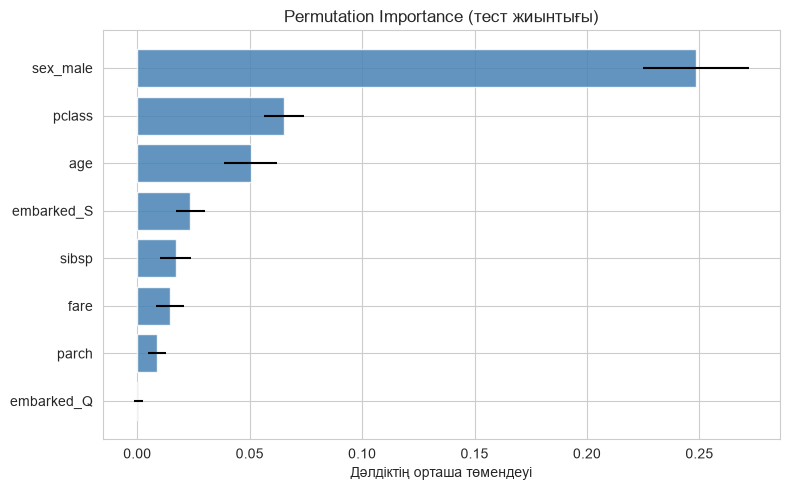

In [17]:
# Пермутациялық маңыздылықты error bar-мен визуализациялау
plt.figure(figsize=(8, 5))
plt.barh(
    importances_perm["feature"],
    importances_perm["importance_mean"],
    xerr=importances_perm["importance_std"],
    color="steelblue",
    alpha=0.85
)
plt.gca().invert_yaxis()
plt.xlabel("Дәлдіктің орташа төмендеуі")
plt.title("Permutation Importance (тест жиынтығы)")
plt.tight_layout()
plt.show()

## 6-бөлім. Екі әдісті салыстыру

Енді екі әдістің нәтижесін бір кестеде жинап, қатар қоямыз. Идеалды жағдайда олар ұқсас реттілік беруі керек, бірақ айырмашылықтар да болуы мүмкін.

In [18]:
# Екі әдісті біріктіру
comparison = importances_builtin.merge(
    importances_perm[["feature", "importance_mean"]],
    on="feature"
).rename(columns={
    "importance": "builtin",
    "importance_mean": "permutation"
})

comparison

,feature,builtin,permutation
0,sex_male,0.450675,0.248473
1,fare,0.173015,0.014504
2,pclass,0.129981,0.065267
3,age,0.107754,0.050382
4,sibsp,0.055946,0.017176
5,parch,0.047071,0.008779
6,embarked_S,0.027076,0.023664
7,embarked_Q,0.008483,0.000382


### ### TODO ###

Салыстыру кестесі негізінде екі бағанды бір графикте, қатар тұрған екі бағаналы диаграмма (grouped bar chart) түрінде көрсетіңіз. Мұндай визуализация екі әдістің айырмашылығын көзбен бағалауға көмектеседі.

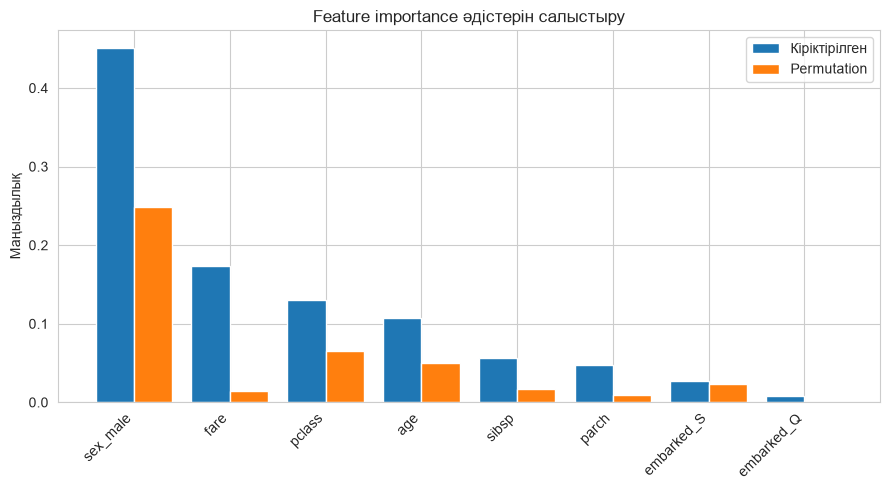

In [20]:
## ### TODO ###
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(comparison))
width = 0.4

ax.bar(x - width/2, comparison["builtin"], width, label="Кіріктірілген")
ax.bar(x + width/2, comparison["permutation"], width, label="Permutation")

ax.set_xticks(x)
ax.set_xticklabels(comparison["feature"], rotation=45, ha="right")
ax.set_ylabel("Маңыздылық")
ax.set_title("Feature importance әдістерін салыстыру")
ax.legend()
plt.tight_layout()
plt.show()

**Талдау сұрағы 2.** Кіріктірілген және пермутациялық маңыздылық арасында реттілік бойынша айырмашылық бар ма? Егер бар болса, қай белгі бойынша және сіздің ойыңызша неге? Кемінде екі сөйлеммен жауап беріңіз.

## 7-бөлім. Қосымша тапсырма (advanced)

Кейде feature importance деректері жаңылыстыруы мүмкін, себебі белгілер өзара корреляцияланған. Мысалы, sex_male белгісі жойылса, қалған белгілер сол ақпаратты ішінара орнын толтыруы мүмкін. Бұл құбылысты өз көзіңізбен көру үшін төмендегі TODO тапсырмасын орындаңыз.

### ### TODO ###

sex_male белгісін оқу жиынтығынан алып тастап, модельді қайта оқытыңыз және дәлдік пен feature importance қалай өзгеретінін бақылаңыз.

In [21]:
## ### TODO ###
# 1. Жаңа оқу және тест жиынтығын дайындау (sex_male бағанасынсыз)
X_train_reduced = X_train.drop(columns=["sex_male"])
X_test_reduced = X_test.drop(columns=["sex_male"])

# 2. Жаңа модельді оқыту
rf_reduced = RandomForestClassifier(
    n_estimators=300, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1
)
rf_reduced.fit(X_train_reduced, y_train)

# 3. Жаңа модельдің дәлдігін есептеу
acc_reduced = accuracy_score(y_test, rf_reduced.predict(X_test_reduced))
print(f"Жаңа дәлдік: {acc_reduced:.4f}")

# 4. Жаңа feature importance-ты шығару
pd.DataFrame({
    "feature": X_train_reduced.columns,
    "importance": rf_reduced.feature_importances_
}).sort_values("importance", ascending=False)

Жаңа дәлдік: 0.7099


,feature,importance
4,fare,0.348421
1,age,0.272302
0,pclass,0.137128
3,parch,0.093145
2,sibsp,0.092345
6,embarked_S,0.043044
5,embarked_Q,0.013615


**Талдау сұрағы 3.** Дәлдік қаншалықты төмендеді? Егер айтарлықтай төмендемесе, бұл нені білдіреді? Корреляцияланған белгілер жағдайында feature importance-ты интерпретациялау неге қиын?

## Қорытынды

Осы зертханалық жұмыста сіз ML модельдерінің шешім қабылдау механизмін түсіндіретін екі маңызды әдісті қолданып көрдіңіз. Кіріктірілген feature importance жылдам және қарапайым, бірақ модельге тәуелді және кардиналдылыққа бейім. Permutation importance модельге тәуелсіз, статистикалық негізі бар, бірақ есептеу қымбат және корреляцияланған белгілер жағдайында дұрыс емес нәтиже беруі мүмкін. Келесі зертханалық жұмыста біз локалды түсіндіру әдісі болып саналатын SHAP-пен танысамыз, ол әр жеке болжамды жеке-жеке түсіндіруге мүмкіндік береді.

## Рефлексия сұрақтары

1. Feature importance мәнінің үлкен болуы — белгінің себеп-салдарлық (causal) фактор екенін білдіре ме? Неге?

2. Егер модельдің дәлдігі жоғары болса, бірақ ең маңызды белгі домен маманының түсінігіне қайшы келсе, сіз қандай әрекет жасар едіңіз?

3. Пермутациялық маңыздылықты оқу жиынтығында да, тест жиынтығында да есептеуге болады. Қайсысы моделдің шынайы жалпылау қабілетін жақсырақ көрсетеді? Неге?